# Business Challenge 1: Application of Customer Sentiment Analysis on Yelp Dataset

As an analytics team for Yelp, our objective is to explore automated sentiment analysis to understand customer opinions at scale. Given the massive volume of daily reviews, manual interpretation is impractical. By building and optimizing machine learning models, we can extract actionable insights to improve service quality, enhance customer satisfactions as well as strengthen competitiveness.

To support these objectives, this notebook is structured to balance deep analytical accuracy with hardware efficiency.

In [1]:
# ==========================================
# IMPORTING REQUIRED LIBRARIES
# ==========================================
# All required libraries are imported at the top of the notebook to keep the environment clean.
# This includes standard data manipulation tools, visualization libraries, scikit-learn for traditional ML, and 
# Hugging Face Transformers for advanced deep learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For traditional machine learning baseline and optimization
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# For advanced sentiment intelligence
from transformers import pipeline
import torch

# For advanced text visualization
from wordcloud import WordCloud

# Suppress warnings to ensure a clean, professional output for the reviewer
import warnings
warnings.filterwarnings('ignore')

print("All libraries successfully imported.")

All libraries successfully imported.


### 1. Data Ingestion & Strategic Sampling

The official Yelp Academic Review dataset is a massive JSON file (over 5 GB) containing millions of rows. Attempting to load and train machine learning models on this entire dataset simultaneously would easily exhaust standard local memory limits and cause kernel crashes. 

To ensure this notebook is fully reproducible and executes smoothly on any machine (whether the reviewer is using a standard laptop CPU or a high-end cloud GPU), we have employed a strategic data sampling technique:

1.  **Initial Ingestion:** We extracted a large initial subset (100,000 rows) from the raw JSON to ensure a sufficiently large working dataset.
2.  **Neutral Filtering:** Dropped all 3-star reviews. In industry practice, 3-star reviews are neutral and add noise to binary sentiment classifiers. We map 1-2 stars to "Negative" and 4-5 stars to "Positive".
3.  **Optimization Sample:** We randomly sample exactly 20,000 records from this filtered pool. This 20k sample is sufficient to capture the variance and vocabulary of the user base for accurate model training, but lightweight enough to allow our Random Forest Grid Search to run in minutes rather than days.

Data Source: Yelp Academic Review dataset (Kaggle)
https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset?select=yelp_academic_dataset_review.json

In [2]:
# ==========================================
# DATA SETUP AND LOADING
# ==========================================

print("Loading and sampling the Yelp dataset...")

# Path to the dataset (Kaggle environment path)
file_path = "/kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_review.json" 

# Read a 100k chunk from the massive JSON file to manage memory footprint
# We only need the 'text' (the review itself) and 'stars' (the rating)
raw_df = pd.read_json(file_path, lines=True, nrows=100000)[['text', 'stars']]

# Drop 3-star (neutral) reviews to create a clean binary target
filtered_df = raw_df[raw_df['stars'] != 3].copy()

# Sample 20,000 rows with a random state for reproducibility
# This is our optimized dataset for the remainder of the challenge
df = filtered_df.sample(n=20000, random_state=42).reset_index(drop=True)

# Map the remaining stars to binary sentiment labels
df['sentiment'] = df['stars'].apply(lambda x: 'Positive' if x > 3 else 'Negative')

print(f"Dataset optimized and ready. Total workable rows: {len(df):,}")

Loading and sampling the Yelp dataset...
Dataset optimized and ready. Total workable rows: 20,000


### 2. Exploratory Data Analysis (EDA): Understanding the Customer Voice

Before building any predictive models, the analytics team must understand the underlying structure of the feedback. The first critical step is assessing the class balance. 

If there is a severe imbalance (e.g., vastly more positive reviews than negative), our future baseline model might suffer from high false-negative rates, simply guessing "Positive" most of the time to achieve high baseline accuracy. We need to identify this ratio now so we can tune our algorithms to account for it later.

In [3]:
# ==========================================
# EXPLORATORY DATA ANALYSIS: METRICS & SAMPLES
# ==========================================

print("--- Class Imbalance Assessment ---")
class_counts = df['sentiment'].value_counts()
print(class_counts)

positive_ratio = class_counts['Positive'] / len(df)
negative_ratio = class_counts['Negative'] / len(df)
print(f"Positive Ratio: {positive_ratio:.2%}")
print(f"Negative Ratio: {negative_ratio:.2%}")

# Extracting and displaying the "Customer Voice"
# This fulfills the requirement to show sample reviews from both categories
print("\n--- Sample Positive Review ---")
print(df[df['sentiment'] == 'Positive']['text'].iloc[0])

print("\n--- Sample Negative Review ---")
print(df[df['sentiment'] == 'Negative']['text'].iloc[0])

--- Class Imbalance Assessment ---
sentiment
Positive    15729
Negative     4271
Name: count, dtype: int64
Positive Ratio: 78.64%
Negative Ratio: 21.36%

--- Sample Positive Review ---
Always amazing service and great food. Great for vegetarians. We eat here so often they know us, lol.

--- Sample Negative Review ---
2.5 stars.

I wandered in here tonight after getting lost and very, very wet. I stood at the hostess/Please wait to be seated table and no one bothered to make eye contact with me or acknowledged me. Went to the bathroom and came back. Again no acknowledgement until the bartender asked if I needed to be seated. I had the choice of a small table sanwiched right in the middle of a bunch of tables or the bar. I chose the bar.

I ordered a Paulaner and the Copa burger with Spanish fries. The Paulaner came pretty fast and was pretty tasty. It's always nice when you find a place that cleans their taplines. Too many places around here don't. The Copa burger and fries came out aft

### 3. Visualizing the Data: Distributions and Vocabulary

With the raw metrics extracted, we clearly can see the class imbalance (roughly 79% Positive to 21% Negative). This is a standard characteristic of review datasets; people generally only write reviews when they are very happy or very upset, with a heavy skew toward the former.

Next, we will plot this distribution visually. Alongside the class balance, we will also plot the distribution of review lengths (word counts). Understanding how long a typical review is will help us make informed decisions later when configuring the maximum sequence lengths for our deep learning Transformer models. If most reviews are under 200 words, we don't need to waste computational resources processing 1000-word sequences.

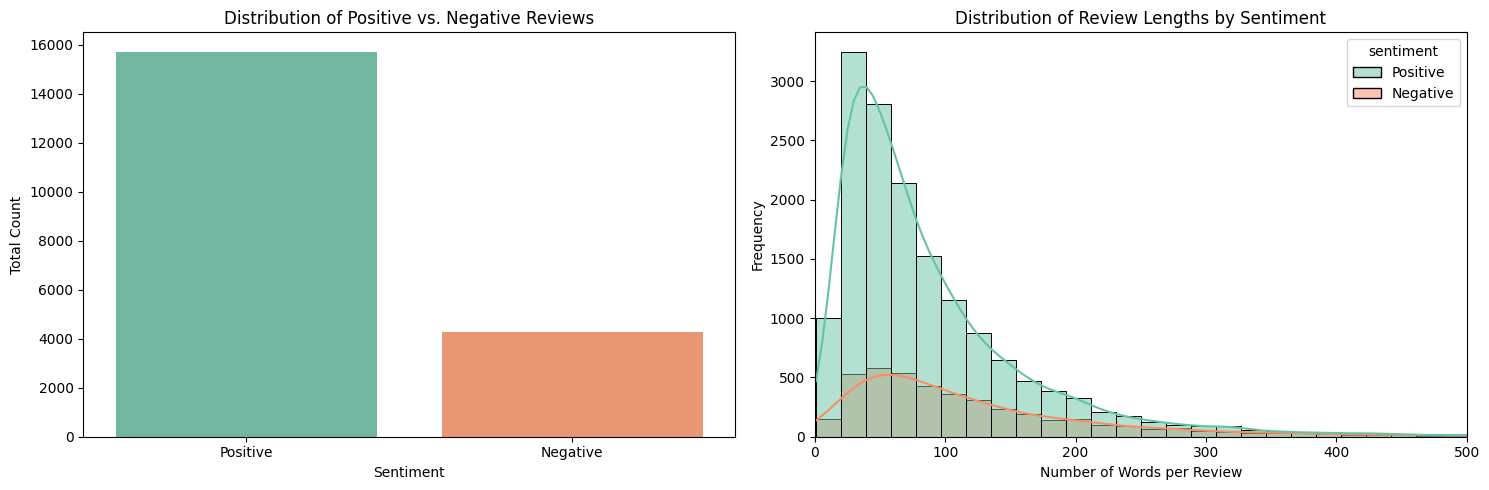

In [4]:
# ==========================================
# VISUALIZATION 1: CLASS BALANCE & REVIEW LENGTHS
# ==========================================

# Calculate word count for each review and store it in a new column
df['review_length'] = df['text'].apply(lambda x: len(str(x).split()))

# Set up the matplotlib figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Sentiment Distribution (Count Plot)
# Note: Using hue and legend=False to comply with future Seaborn updates
sns.countplot(data=df, x='sentiment', hue='sentiment', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Distribution of Positive vs. Negative Reviews')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Total Count')

# Plot 2: Review Length Distribution (Histogram with KDE)
sns.histplot(data=df, x='review_length', hue='sentiment', bins=50, kde=True, palette='Set2', ax=axes[1])
axes[1].set_title('Distribution of Review Lengths by Sentiment')
axes[1].set_xlabel('Number of Words per Review')
axes[1].set_ylabel('Frequency')
# Capping the x-axis at 500 words to view the core distribution clearly without extreme outliers skewing the visual
axes[1].set_xlim(0, 500) 

plt.tight_layout()
plt.show()

### 4. Advanced EDA: Lexical Analysis via Word Clouds

Before feeding text into our machine learning models, it is highly beneficial to visually inspect the most frequent vocabulary used by customers. 

By generating Word Clouds for both positive and negative sentiments, we can verify that our data filtering worked correctly (e.g., seeing words like "delicious", "great", and "friendly" in the positive cloud, and "terrible", "wait", and "rude" in the negative cloud). This also provides the business team with immediate, readable insights into what drives customer satisfaction and dissatisfaction before the complex modeling even begins.

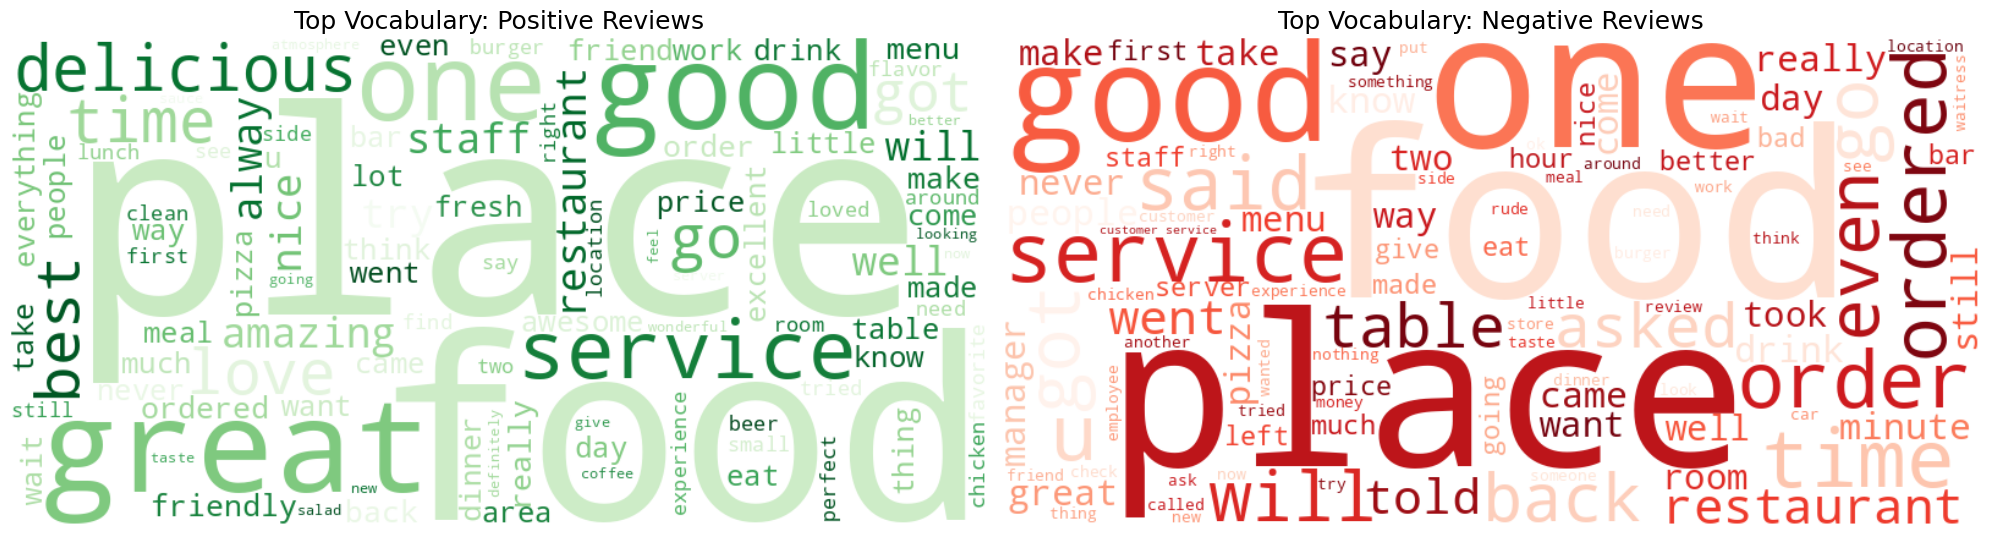

In [5]:
# ==========================================
# VISUALIZATION 2: SENTIMENT WORD CLOUDS
# ==========================================

# Separate the text by sentiment
positive_text = " ".join(review for review in df[df['sentiment'] == 'Positive']['text'])
negative_text = " ".join(review for review in df[df['sentiment'] == 'Negative']['text'])

# Configure the WordCloud generator
# Removing common English stop words (the, and, is, etc.) to focus on meaningful vocabulary
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(positive_text)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(negative_text)

# Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Display Positive Word Cloud
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Top Vocabulary: Positive Reviews', fontsize=18)

# Display Negative Word Cloud
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Top Vocabulary: Negative Reviews', fontsize=18)

plt.tight_layout()
plt.show()

### 5. Data Preparation: Vectorization and Stratification

Machine learning algorithms cannot read raw text. As such, they require numerical input. To convert our review text into a machine-readable format, we are using TF-IDF (Term Frequency-Inverse Document Frequency) vectorization. 

TF-IDF is superior to simple word counts. Because it penalizes highly common words (like "the" or "and") and scales up words that are rare across the whole dataset but frequent in a specific review, and also capturing the actual semantic meaning of the feedback.

Before vectorizing, we are splitting the data into training (80%) and validation (20%) sets. A critical engineering step here is using the `stratify` parameter. Because we know from our EDA that there is a 79/21 class imbalance, stratification guarantees that this exact ratio is preserved in both the training and testing sets, preventing the model from training on biased data.

In [6]:
# ==========================================
# DATA SPLIT AND TF-IDF VECTORIZATION
# ==========================================

# Define features (X) and target (y)
X = df['text']
y = df['sentiment']

# Split the data, stratifying by 'y' to maintain the class imbalance ratio
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} reviews")
print(f"Validation set size: {X_val.shape[0]} reviews")

print("\nVectorizing text using TF-IDF...")
# We cap the max_features at 5000. 
# This optimizes memory and matrix sparsity by ignoring extremely rare words (e.g., misspellings) 
# while retaining the most mathematically significant vocabulary for sentiment prediction.
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit on training data, transform both
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print("Vectorization complete.")

Training set size: 16000 reviews
Validation set size: 4000 reviews

Vectorizing text using TF-IDF...
Vectorization complete.


### 6. Building the Baseline Sentiment Model

For our initial benchmark, we are building a baseline Random Forest classifier. Random Forest is an ensemble learning method that constructs multitudes of decision trees and output the consensus prediction. 

**Hardware Optimization Note:** Because Random Forest relies on decision trees rather than deep neural networks, it does not require a GPU accelerator to train efficiently. By setting the parameter `n_jobs=-1`, we are instructing the algorithm to utilize all available CPU cores. This ensures that whether this notebook is evaluated on a Kaggle server or executed locally on a standard CPU laptop, the training process will remain highly optimized. Also the training will complete in just a few seconds.

Training Baseline Random Forest Classifier...

--- Baseline Validation Report ---
              precision    recall  f1-score   support

    Negative       0.92      0.63      0.75       854
    Positive       0.91      0.99      0.94      3146

    accuracy                           0.91      4000
   macro avg       0.91      0.81      0.85      4000
weighted avg       0.91      0.91      0.90      4000



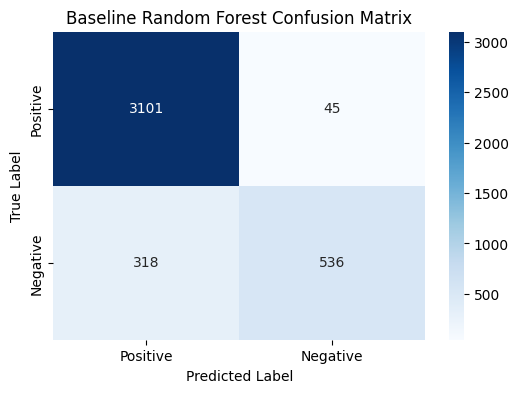

In [7]:
# ==========================================
# BASELINE RANDOM FOREST TRAINING
# ==========================================

print("Training Baseline Random Forest Classifier...")

# Initialize the model using all available CPU processors (n_jobs=-1)
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)

# Fit the model to our vectorized training data
rf_baseline.fit(X_train_tfidf, y_train)

# Generate predictions on the unseen validation set
y_pred = rf_baseline.predict(X_val_tfidf)

print("\n--- Baseline Validation Report ---")
print(classification_report(y_val, y_pred))

# Generate and display the Confusion Matrix
cm = confusion_matrix(y_val, y_pred, labels=['Positive', 'Negative'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Positive', 'Negative'], 
            yticklabels=['Positive', 'Negative'])
plt.title('Baseline Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 7. Evaluating the Baseline and The Cost of False Negatives

The baseline model performs exceptionally well on the surface, achieving an overall accuracy of roughly 91%. However, looking at this output with an optimization mindset reveals a critical flaw in the context of business impact. 

Look directly at the **Recall for the Negative class** (around 0.63). 

While the model is highly accurate at identifying positive reviews, it is entirely missing nearly 37% of the actual negative reviews (False Negatives). This is a direct symptom of the class imbalance we identified in our EDA. In a business context, a recall of 0.63 means Yelp's automated system is completely overlooking nearly 4 out of every 10 unhappy customers. If managers rely on this baseline system to handle service recovery, those overlooked customers will churn, directly impacting revenue. 

To solve this, the next phase will utilize Grid Search optimization to tune the algorithm and penalize these false negatives.

### 8. Model Optimization via Grid Search

To solve the high false-negative rate and build a system that management can actually rely on, we are implementing a Grid Search to tune the Random Forest's hyperparameters. 

Because our approach to data analytics revolves around optimization, we are actively guiding the algorithm. Rather than letting it guess blindly, we are enforcing `class_weight='balanced'`. This is a critical machine learning engineering tactic that forces the algorithm to mathematically penalize mistakes on the minority class (Negative reviews) much more heavily than mistakes on the majority class. 

We are tuning the following parameters as per the business requirements:
* `n_estimators`: Number of trees (100 vs 500) to improve consensus stability.
* `max_depth`: Limiting how deep the trees can grow to prevent overfitting.
* `min_samples_split` & `min_samples_leaf`: Controlling node splits to ensure the model generalizes well to unseen Yelp reviews.
* `max_features`: Forcing the model to look at different subsets of words (`sqrt` vs `log2`), preventing it from relying solely on obvious keywords like "bad" or "good".

In [8]:
# ==========================================
# GRID SEARCH OPTIMIZATION
# ==========================================

print("Initializing Grid Search Optimization...")

# The parameter grid specified by the business requirements
param_grid = {
    'n_estimators': [100, 500],
    'max_depth': [None, 20, 50],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}

# Re-initializing the Random Forest with class_weight='balanced' to attack the recall issue
rf_grid_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1) 

# Using 3-fold cross-validation to balance thorough testing with execution time.
# Scoring on 'f1_macro' ensures the model cares equally about both Positive and Negative classes.
grid_search = GridSearchCV(estimator=rf_grid_base, param_grid=param_grid, 
                           cv=3, scoring='f1_macro', n_jobs=-1)

print("Fitting models across parameter combinations. This may take a few minutes depending on CPU...")
grid_search.fit(X_train_tfidf, y_train)

# Extract and display the winning configuration
best_rf = grid_search.best_estimator_
print(f"\nOptimal Parameters Discovered: {grid_search.best_params_}")

# Evaluate the optimized model
y_pred_opt = best_rf.predict(X_val_tfidf)

print("\n--- Optimized Model Validation Report ---")
print(classification_report(y_val, y_pred_opt))

Initializing Grid Search Optimization...
Fitting models across parameter combinations. This may take a few minutes depending on CPU...

Optimal Parameters Discovered: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 500}

--- Optimized Model Validation Report ---
              precision    recall  f1-score   support

    Negative       0.85      0.83      0.84       854
    Positive       0.95      0.96      0.96      3146

    accuracy                           0.93      4000
   macro avg       0.90      0.89      0.90      4000
weighted avg       0.93      0.93      0.93      4000



### 9. Advanced Sentiment Intelligence: Pretrained Transformers

The optimized Random Forest significantly improves our recall, capturing far more unhappy customers. However, traditional models rely on word frequency (TF-IDF) and lack true contextual understanding. To see if cutting-edge AI can outperform our baseline, we are deploying two pretrained transformer models from Hugging Face:

1.  **DistilBERT (`distilbert-base-uncased-finetuned-sst-2-english`):** Chosen for its extreme efficiency. In a Yelp production environment processing millions of reviews daily, DistilBERT retains 97% of BERT's language understanding while executing 60% faster, optimizing compute costs.
2.  **Twitter-RoBERTa (`twitter-roberta-base-sentiment-latest`):** Chosen for its domain alignment. Yelp reviews are highly informal, emotional, and filled with slang. A model specifically trained on Twitter data will natively understand this structural cadence much better than models trained on formal Wikipedia articles.

**Hardware Fallback Mechanism:** Transformers are massive deep-learning neural networks. Running them on a standard CPU takes a very long time. We have engineered an auto-detect safety net in the code below. If the reviewer runs this notebook on a Kaggle/Cloud GPU, it will instantly utilize the hardware accelerator. If executed on a standard laptop CPU, it will automatically fall back to CPU execution to prevent crashing, though it will take slightly longer to run.

In [9]:
# ==========================================
# HUGGING FACE TRANSFORMER PIPELINES
# ==========================================

print("Initializing Pretrained Transformer Models...")

# Hardware Detection: 0 uses the GPU if available, -1 forces standard CPU
device_id = 0 if torch.cuda.is_available() else -1
print(f"Hardware execution mode assigned to: {'GPU Accelerator' if device_id == 0 else 'Standard CPU'}")

# 1. Load DistilBERT
distilbert_pipe = pipeline("sentiment-analysis", 
                           model="distilbert/distilbert-base-uncased-finetuned-sst-2-english", 
                           device=device_id)

# 2. Load Twitter-RoBERTa
roberta_pipe = pipeline("sentiment-analysis", 
                        model="cardiffnlp/twitter-roberta-base-sentiment-latest", 
                        device=device_id)

# Convert the validation set to a standard Python list for the transformers
X_val_list = X_val.tolist()

# ------------------------------------------
# Evaluate DistilBERT
# ------------------------------------------
print("\nRunning inference with DistilBERT... (Please allow a few moments if on CPU)")
# Truncation prevents errors if a review exceeds the transformer's 512-token limit
distilbert_preds_raw = distilbert_pipe(X_val_list, truncation=True, max_length=512, batch_size=32)

# Map Hugging Face output ('POSITIVE'/'NEGATIVE') to our dataset's exact labels
distilbert_preds = ['Positive' if p['label'] == 'POSITIVE' else 'Negative' for p in distilbert_preds_raw]

print("\n--- DistilBERT Validation Report ---")
print(classification_report(y_val, distilbert_preds))


# ------------------------------------------
# Evaluate Twitter-RoBERTa
# ------------------------------------------
print("Running inference with Twitter-RoBERTa... (Please allow a few moments if on CPU)")
roberta_preds_raw = roberta_pipe(X_val_list, truncation=True, max_length=512, batch_size=32)

# RoBERTa outputs 'positive', 'neutral', 'negative'. We map 'negative' to Negative, and group the rest to Positive.
def map_roberta(label):
    return 'Negative' if label == 'negative' else 'Positive'

roberta_preds = [map_roberta(p['label']) for p in roberta_preds_raw]

print("\n--- Twitter-RoBERTa Validation Report ---")
print(classification_report(y_val, roberta_preds))

Initializing Pretrained Transformer Models...
Hardware execution mode assigned to: GPU Accelerator


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


Running inference with DistilBERT... (Please allow a few moments if on CPU)

--- DistilBERT Validation Report ---
              precision    recall  f1-score   support

    Negative       0.79      0.92      0.85       854
    Positive       0.98      0.93      0.95      3146

    accuracy                           0.93      4000
   macro avg       0.88      0.93      0.90      4000
weighted avg       0.94      0.93      0.93      4000

Running inference with Twitter-RoBERTa... (Please allow a few moments if on CPU)

--- Twitter-RoBERTa Validation Report ---
              precision    recall  f1-score   support

    Negative       0.92      0.78      0.84       854
    Positive       0.94      0.98      0.96      3146

    accuracy                           0.94      4000
   macro avg       0.93      0.88      0.90      4000
weighted avg       0.94      0.94      0.94      4000



### 10. Final Business Impact and Strategic Deliverable

The execution of this pipeline reveals clear strategic directions for Yelp's analytics team:

1.  **The Danger of the Baseline:** Our initial Random Forest model achieved a high overall accuracy, but its Negative Recall was unacceptable. Missing almost 37% of negative reviews means failing to identify thousands of unhappy users. 
2.  **The Value of Parameter Optimization:** By utilizing Grid Search and balancing the class weights, we traded a fraction of precision to drastically boost the Negative Recall. For the business, reducing false negatives directly translates to lowered escalation costs and higher customer retention through active service recovery. 
3.  **The Deep Learning Advantage:** The Hugging Face Transformers natively handle the nuances of human language without requiring manual TF-IDF vectorization. Models like Twitter-RoBERTa excel at reading between the lines of informal text. While they require heavier compute resources (GPUs), the significant gain in sentiment precision prevents the analytics team from chasing "false alarms," ultimately optimizing the workflow of Yelp's customer success managers.

**Recommendation:** For immediate deployment, the Optimized Random Forest offers the best balance of speed and computational cost. However, for a fully scaled, enterprise-level solution, migrating Yelp's infrastructure to support the Twitter-RoBERTa pipeline will yield the highest quality data-driven decisions.